# Set-up

In [7]:
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

In [8]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [9]:
path_out = "/cellar/users/aklie/projects/igvf/sc-islet-design/scratch/2025_04_02"

# Load genome

In [10]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg19/hg19.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [11]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg19/hg19.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load model

In [12]:
path_model = "/cellar/users/aklie/data/datasets/HPAP/models/Beta/fold_0/chrombpnet/0.3/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

# Load sequences

In [15]:
original_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTGGTGAAAACAATCTGAGGAGAACAAGGGCTCTGTTTTTTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()
mutated_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTTGTGTAAACAATCTGAGGTAAACAAGGGCTCTGTTTACTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()

In [16]:
len(original_seq), len(mutated_seq)

(2114, 2114)

In [17]:
# Find all the differences between the original and mutated sequences, both the change and the position
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(1032, 'G', 'T'),
 (1036, 'A', 'T'),
 (1050, 'A', 'T'),
 (1051, 'G', 'A'),
 (1068, 'T', 'A'),
 (1069, 'T', 'C')]

# ISM

In [19]:
from tangermeme.ism import saturation_mutagenesis

In [60]:
seq_len = 2114
target_len = 1000

In [61]:
window = 500
seq_center = 2114 // 2
seq_start = seq_center - window // 2
seq_end = seq_center + window // 2
seq_start, seq_end

(807, 1307)

In [29]:
X = torch.tensor(np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA).transpose(), axis=0), dtype=torch.float32)

In [34]:
from bpnetlite.bpnet import CountWrapper

In [37]:
count_wrapper = CountWrapper(model).to('cuda')  

In [40]:
count_wrapper(X.cuda()).shape

torch.Size([1, 1])

In [65]:
res = saturation_mutagenesis(
    count_wrapper,
    X,
    #start=0,
    #end=,
    hypothetical=False,  
    verbose=True,
)

100%|██████████| 265/265 [00:08<00:00, 32.27it/s]


In [66]:
window = 200
seq_center = 2114 // 2
plot_center = 1050
offset = plot_center - seq_center
seq_start = seq_center - window // 2
seq_end = seq_center + window // 2
target_start = (target_len // 2 - window // 2) + offset
target_end = (target_len // 2 + window // 2) + offset

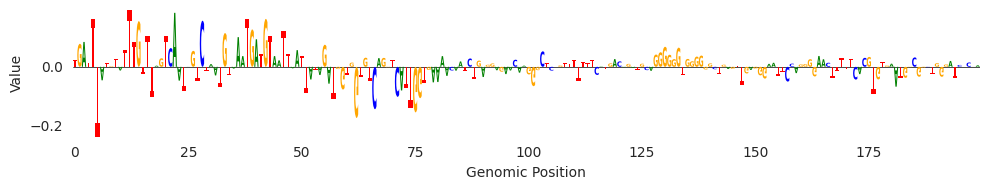

In [67]:
plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(res[0, :, seq_start:seq_end], ax=ax)

plt.xlabel("Genomic Position")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [18]:
revcomp_original_seq = sp.reverse_complement(original_seq, sp.DNA)
revcomp_mutated_seq = sp.reverse_complement(mutated_seq, sp.DNA)
original_seq_onehot = np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
revcomp_original_seq_onehot = np.expand_dims(sp.ohe(revcomp_original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
revcomp_mutated_seq_onehot = np.expand_dims(sp.ohe(revcomp_mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
original_seq_onehot.shape, revcomp_original_seq_onehot.shape, mutated_seq_onehot.shape, revcomp_mutated_seq_onehot.shape

((1, 4, 2114), (1, 4, 2114), (1, 4, 2114), (1, 4, 2114))

In [78]:
fwd_original_profile, fwd_original_counts = predict(model, torch.tensor(original_seq_onehot).float().cuda())
rev_original_profile, rev_original_counts = predict(model, torch.tensor(revcomp_original_seq_onehot).float().cuda())
fwd_original_counts = np.squeeze(np.exp(fwd_original_counts.cpu().detach().numpy()))
rev_original_counts = np.squeeze(np.exp(rev_original_counts.cpu().detach().numpy()))
fwd_original_profile = np.squeeze(torch.exp(log_softmax_profile(fwd_original_profile)).cpu().detach().numpy())
rev_original_profile = np.squeeze(torch.exp(log_softmax_profile(rev_original_profile)).cpu().detach().numpy())
original_counts = (fwd_original_counts + rev_original_counts) / 2
original_profile = (fwd_original_profile + rev_original_profile) / 2

fwd_mutated_profile, fwd_mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
rev_mutated_profile, rev_mutated_counts = predict(model, torch.tensor(revcomp_mutated_seq_onehot).float().cuda())
fwd_mutated_counts = np.squeeze(np.exp(fwd_mutated_counts.cpu().detach().numpy()))
rev_mutated_counts = np.squeeze(np.exp(rev_mutated_counts.cpu().detach().numpy()))
fwd_mutated_profile = np.squeeze(torch.exp(log_softmax_profile(fwd_mutated_profile)).cpu().detach().numpy())
rev_mutated_profile = np.squeeze(torch.exp(log_softmax_profile(rev_mutated_profile)).cpu().detach().numpy())
mutated_counts = (fwd_mutated_counts + rev_mutated_counts) / 2
mutated_profile = (fwd_mutated_profile + rev_mutated_profile) / 2

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original counts: 2247.2788675435495
mutated counts: 5752.601375189747


In [79]:
original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

((1000,), (1000,))

# Attribution

In [73]:
dtype = torch.float64
count_wrapper = CountWrapper(ControlWrapper(model)).cuda().eval()

In [69]:
# Get attribution scores for the original sequence
X_attr_counts = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(original_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

100%|██████████| 20/20 [02:29<00:00,  7.46s/it]


In [ ]:
# Get attribution scores for the mutated sequence
X_attr_counts_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

100%|██████████| 20/20 [00:06<00:00,  3.12it/s]


# Plot

In [127]:
seq_len = 2114
target_len = 1000

In [128]:
chrom = "chr4"
start = 84432784
end = 84434897

In [129]:
window = 200
seq_center = 2114 // 2
plot_center = 1050
offset = plot_center - seq_center
offset

-7

In [130]:
seq_start = seq_center - window // 2
seq_end = seq_center + window // 2
target_start = (target_len // 2 - window // 2) + offset
target_end = (target_len // 2 + window // 2) + offset
ref_start = start + seq_start
ref_end = start + seq_end
seq_start, seq_end, target_start, target_end, ref_start, ref_end

(957, 1157, 393, 593, 84433741, 84433941)

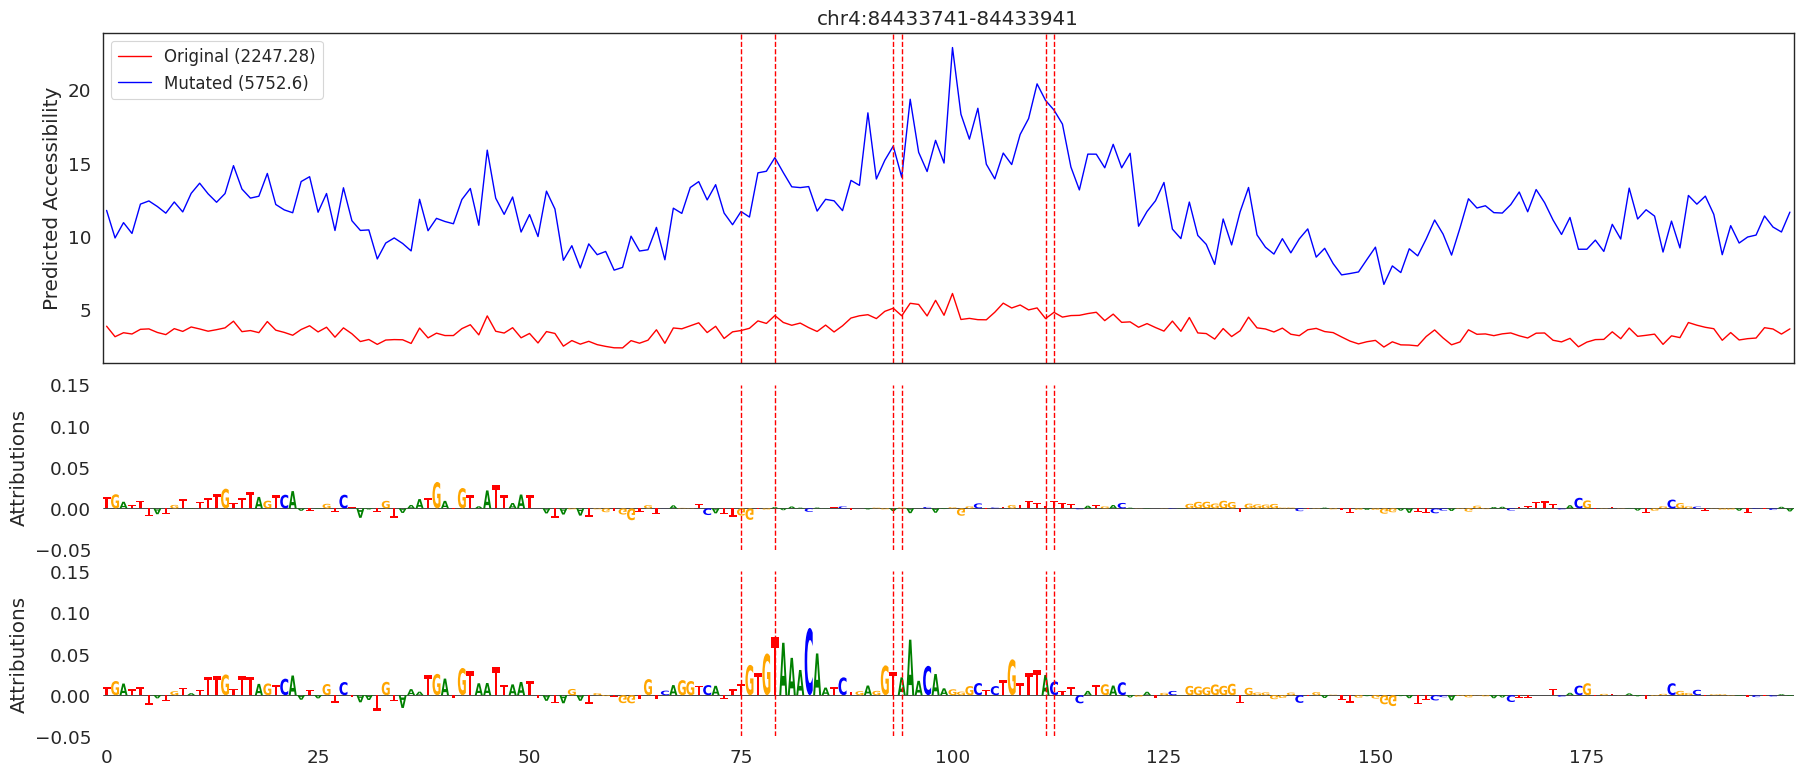

In [131]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, window), original_pred[target_start:target_end], color='r', linewidth=1, label=f"Original ({round(original_counts, 2)})")
    axes[0].plot(range(0, window), mutated_pred[target_start:target_end], color='b', linewidth=1, label=f"Mutated ({round(mutated_counts, 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_counts[0, :, seq_start:seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_counts_mutated[0, :, seq_start:seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - seq_start
        axes[0].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(f"{path_out}/NKX6-1_predicted_FOXA_optimization_{window}.pdf", dpi=300)
